#COMPREHENSIVE EXPLORATORY DATA ANALYSIS

 **Dataset Source:** https://www.kaggle.com/datasets/winterbreeze/fifa19eda

##1. ENVIRONMENT SETUP AND DATA LOADING

###1.1 Setting up Kaggle and downloading the dataset

In [1]:
from google.colab import files
files.upload() # uploading the kaggle.json file

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"parantapguha2005","key":"6063e819a55efba7a6840a90c7f0c4e9"}'}

In [2]:
#relocating the kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
# Downloading the dataset directly from kaggle
!kaggle datasets download -d winterbreeze/fifa19eda

Dataset URL: https://www.kaggle.com/datasets/winterbreeze/fifa19eda
License(s): other
100% 605k/605k [00:00<00:00, 93.1MB/s]



In [4]:
# Unzipping the downloaded file
!unzip -o fifa19eda.zip

Archive:  fifa19eda.zip
  inflating: fifa_eda.csv            


###1.2 Loading important libaries and the dataset

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Loading the dataset
df = pd.read_csv('fifa_eda.csv')

In [7]:
# Displaying the first 10 rows
df.head(10)

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500.0,565.0,Left,5.0,4.0,RF,2004,2021-01-01,5.583333,159.0,226500.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000.0,405.0,Right,5.0,5.0,ST,2018,2022-01-01,6.166667,183.0,127100.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.0,290.0,Right,5.0,5.0,LW,2017,2022-01-01,5.750000,150.0,228100.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,1.0,GK,2011,2020-01-01,6.333333,168.0,138600.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000.0,355.0,Right,4.0,4.0,RCM,2015,2023-01-01,5.916667,154.0,196400.0
5,183277,E. Hazard,27,Belgium,91,91,Chelsea,93000.0,340.0,Right,4.0,4.0,LF,2012,2020-01-01,5.666667,163.0,172100.0
6,177003,L. Modrić,32,Croatia,91,91,Real Madrid,67000.0,420.0,Right,4.0,4.0,RCM,2012,2020-01-01,5.666667,146.0,137400.0
7,176580,L. Suárez,31,Uruguay,91,91,FC Barcelona,80000.0,455.0,Right,5.0,3.0,RS,2014,2021-01-01,6.000000,190.0,164000.0
8,155862,Sergio Ramos,32,Spain,91,91,Real Madrid,51000.0,380.0,Right,4.0,3.0,RCB,2005,2020-01-01,6.000000,181.0,104600.0
9,200389,J. Oblak,25,Slovenia,90,93,Atlético Madrid,68000.0,94.0,Right,3.0,1.0,GK,2014,2021-01-01,6.166667,192.0,144500.0


## 2. STRUCTURAL INSPECTION

###2.1 Checking data types and memory usage

In [8]:
print("--- Dataframe Info ---")
df.info()

--- Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        18207 non-null  int64  
 1   Name                      18207 non-null  object 
 2   Age                       18207 non-null  int64  
 3   Nationality               18207 non-null  object 
 4   Overall                   18207 non-null  int64  
 5   Potential                 18207 non-null  int64  
 6   Club                      17966 non-null  object 
 7   Value                     17955 non-null  float64
 8   Wage                      18207 non-null  float64
 9   Preferred Foot            18207 non-null  object 
 10  International Reputation  18159 non-null  float64
 11  Skill Moves               18159 non-null  float64
 12  Position                  18207 non-null  object 
 13  Joined                    18207 non-nu

There are `18` features, among which `6` are categorical (`object`) and `12` are numerical (`int64`,`float64`) features in this dataset.

###2.2 Descriptive statistics for all numerical columns

In [9]:
print("\n--- Descriptive Statistics ---")
df.describe()


--- Descriptive Statistics ---


,ID,Age,Overall,Potential,Value,Wage,International Reputation,Skill Moves,Joined,Height,Weight,Release Clause
count,18207.000000,18207.000000,18207.000000,18207.000000,17955.000000,18207.000000,18159.000000,18159.000000,18207.000000,18207.000000,18207.000000,18207.000000
mean,214298.338606,25.122206,66.238699,71.307299,2444.530214,9.731312,1.113222,2.361308,2016.420607,5.946771,165.979129,4585.060971
std,29965.244204,4.669943,6.908930,6.136496,5626.715434,21.999290,0.394031,0.756164,2.018194,0.220514,15.572775,10630.414430
min,16.000000,16.000000,46.000000,48.000000,10.000000,0.000000,1.000000,1.000000,1991.000000,5.083333,110.000000,13.000000
25%,200315.500000,21.000000,62.000000,67.000000,325.000000,1.000000,1.000000,2.000000,2016.000000,5.750000,154.000000,570.000000
50%,221759.000000,25.000000,66.000000,71.000000,700.000000,3.000000,1.000000,2.000000,2017.000000,5.916667,165.000000,1300.000000
75%,236529.500000,28.000000,71.000000,75.000000,2100.000000,9.000000,1.000000,3.000000,2018.000000,6.083333,176.000000,4585.060806
max,246620.000000,45.000000,94.000000,95.000000,118500.000000,565.000000,5.000000,5.000000,2018.000000,6.750000,243.000000,228100.000000


###2.3 Reporting the number of rows and features in the dataset

In [10]:
print(f"Dataset Shape: {df.shape[0]} tuples, {df.shape[1]} features\n")

Dataset Shape: 18207 tuples, 18 features



###2.4 Listing all the names of the features present in the dataset

In [11]:
print("Columns in Dataset:")
columns=df.columns
for column in columns:
    print(f"- {column}")

Columns in Dataset:
- ID
- Name
- Age
- Nationality
- Overall
- Potential
- Club
- Value
- Wage
- Preferred Foot
- International Reputation
- Skill Moves
- Position
- Joined
- Contract Valid Until
- Height
- Weight
- Release Clause


## 3. DATA CLEANING (The Preprocessing Phase)

###3.1 Missing Value Analysis


Identifying if any features contain `null` values to prevent model errors and determine if we need to drop or impute using `mean`, `median` or `mode`.

In [12]:
print("Missing values per column:\n")
df.isnull().sum()

Missing values per column:



,0
ID,0
Name,0
Age,0
Nationality,0
Overall,0
Potential,0
Club,241
Value,252
Wage,0
Preferred Foot,0


As we can see there are missing values present in `club`, `Value`, `International Reputation`, `Skill Moves`, `Contract Valid Until` columns. Among which `club` and `Contract Valid Until` are categorical and others are numerical.

So, we are separating the numerical and categorical columns into `num_cols` and `cat_cols` respectively.

In [13]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

As there are `200` to `300` null values in a `18000` tuple dataset. Null values comprise less than `2%` of the data so we can easily handle them without disturbing the pattern of data.
- `Value`,`International Reputation`, `Skill Moves` are numerical columns and can be filled in with `mean`.
- `club` and `Contract Valid Until` are both categorical columns and have unpredictable values so we will drop them instead of filling them up using `mode`.

In [14]:
df[num_cols]=df[num_cols].fillna(df[num_cols].mean())
df.dropna(subset=['Club', 'Contract Valid Until'], inplace=True)

In [15]:
print("Total Missing values in the dataset after cleaning: ",df.isnull().sum().sum(),"\n")

Total Missing values in the dataset after cleaning:  0 



There are `0` null values in the dataset showing that we have successfully dealt with them.

###3.2 Duplicate Handling

Removing duplicate entries to ensure our analysis and subsequent models are not biased by redundant data.

Checking for duplicate rows in the dataset

In [16]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


As we can see there are no duplicates in the dataset so we wont be dropping them.

In [17]:
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed successfully.")
else :
    print("No duplicates found in the dataset.")

No duplicates found in the dataset.


###3.3 Data Type Correction

Enforcing proper data types (like converting objects to categories or datetimes) optimizes memory and enables correct plotting/modeling.

We are focusing on `Contract Valid Until` as the values in the dataset are in the specific format of `datetime`. Also we need to change the data type of all `object` columns to `category`.

In [18]:
for column in df.columns:
    if column == 'Contract Valid Until' or column == 'Joined':
        df[column] = pd.to_datetime(df[column])
        print(f"Converted '{column}' column to datetime type.")
    elif df[column].dtype == 'object':
        df[column] = df[column].astype('category')
        print(f"Converted '{column}' column to category type.")

Converted 'Name' column to category type.
Converted 'Nationality' column to category type.
Converted 'Club' column to category type.
Converted 'Preferred Foot' column to category type.
Converted 'Position' column to category type.
Converted 'Joined' column to datetime type.
Converted 'Contract Valid Until' column to datetime type.


Cross checking if all the datatypes of columns have changed

In [19]:
print("\nUpdated Data Types:")
print(df.dtypes)


Updated Data Types:
ID                                   int64
Name                              category
Age                                  int64
Nationality                       category
Overall                              int64
Potential                            int64
Club                              category
Value                              float64
Wage                               float64
Preferred Foot                    category
International Reputation           float64
Skill Moves                        float64
Position                          category
Joined                      datetime64[ns]
Contract Valid Until        datetime64[ns]
Height                             float64
Weight                             float64
Release Clause                     float64
dtype: object


## 4. UNIVARIATE ANALYSIS

###4.1 Numerical Feature Distribution

We use histograms and boxplots to visualize the distribution, check for skewness, and spot potential outliers.

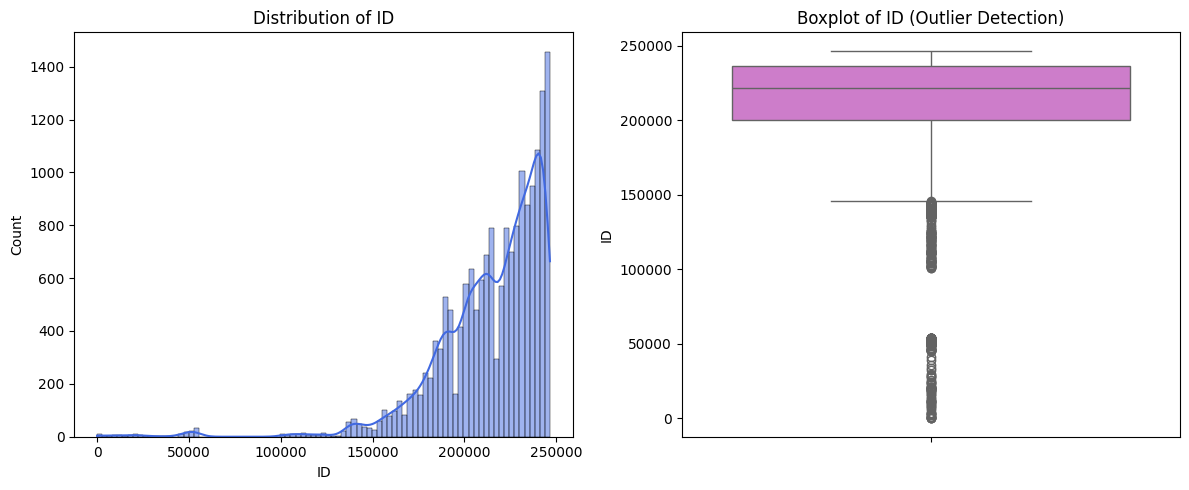

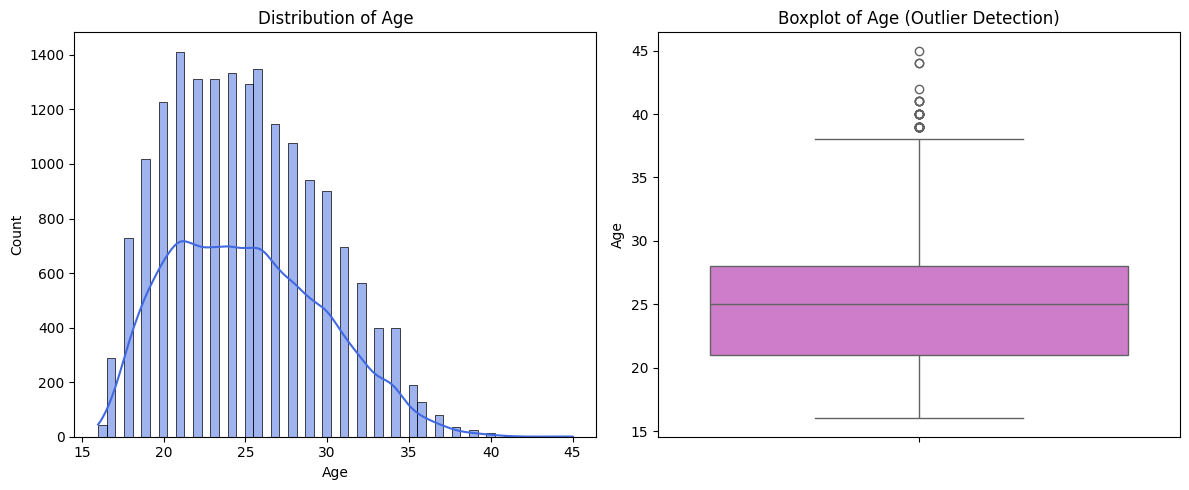

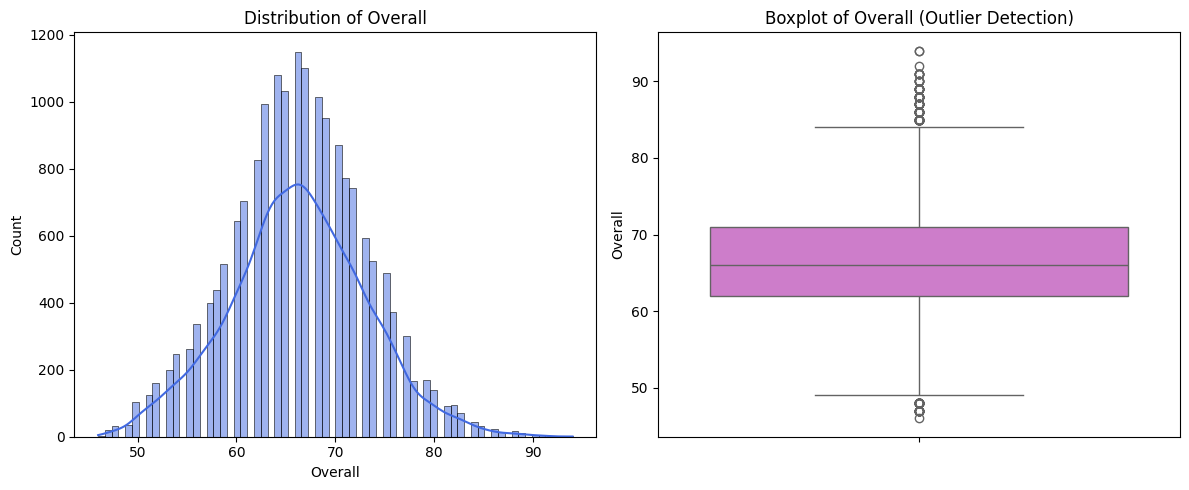

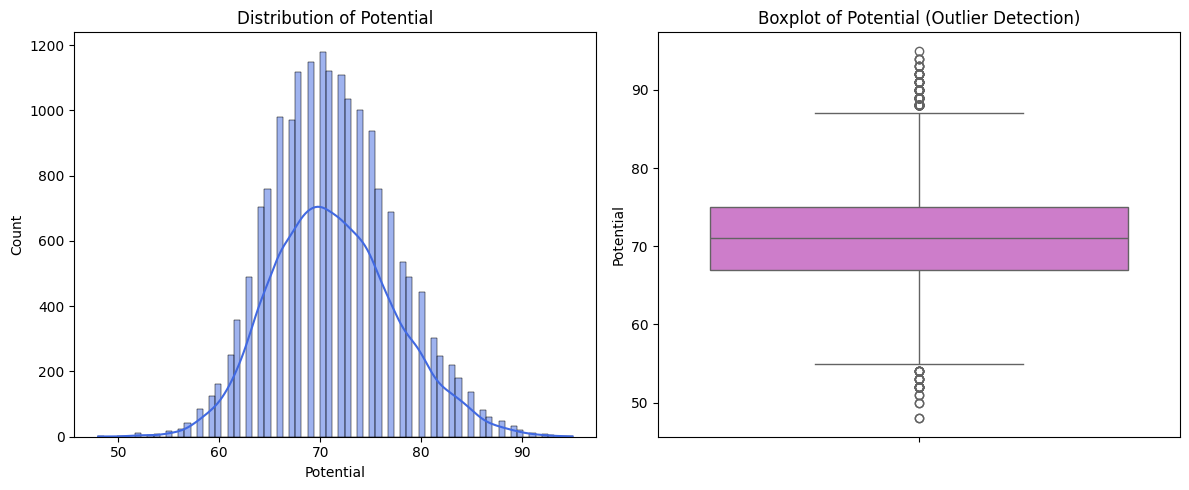

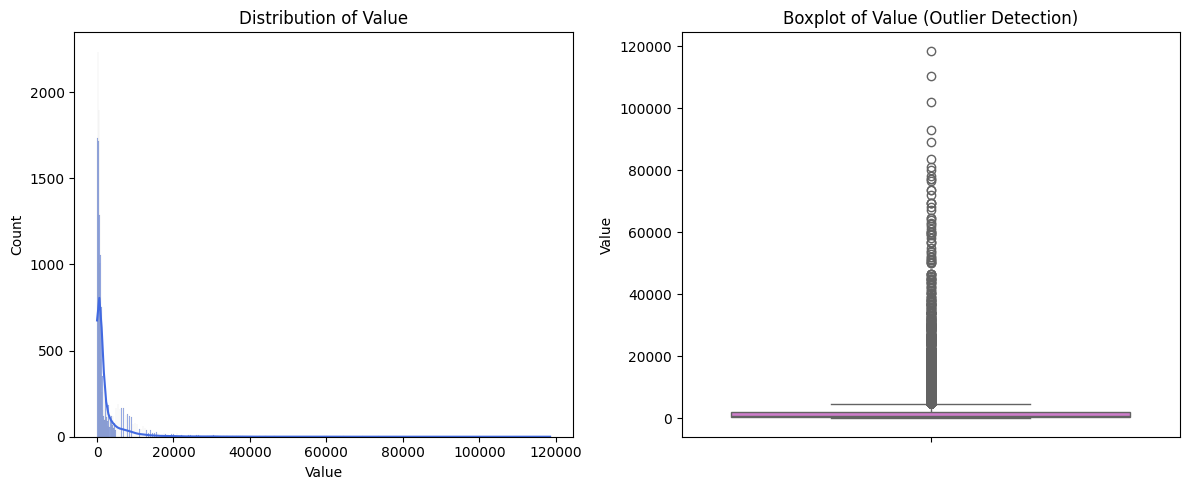

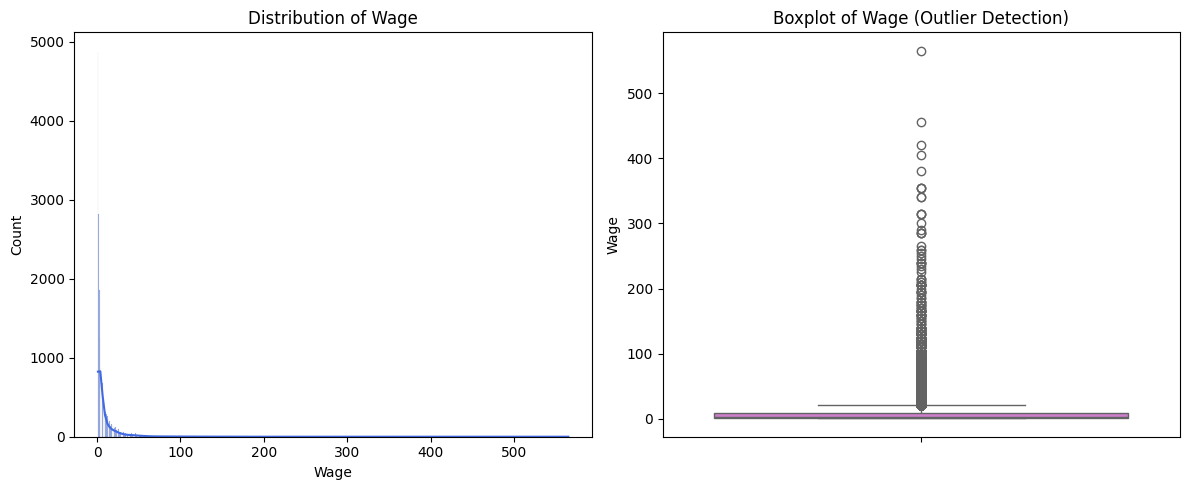

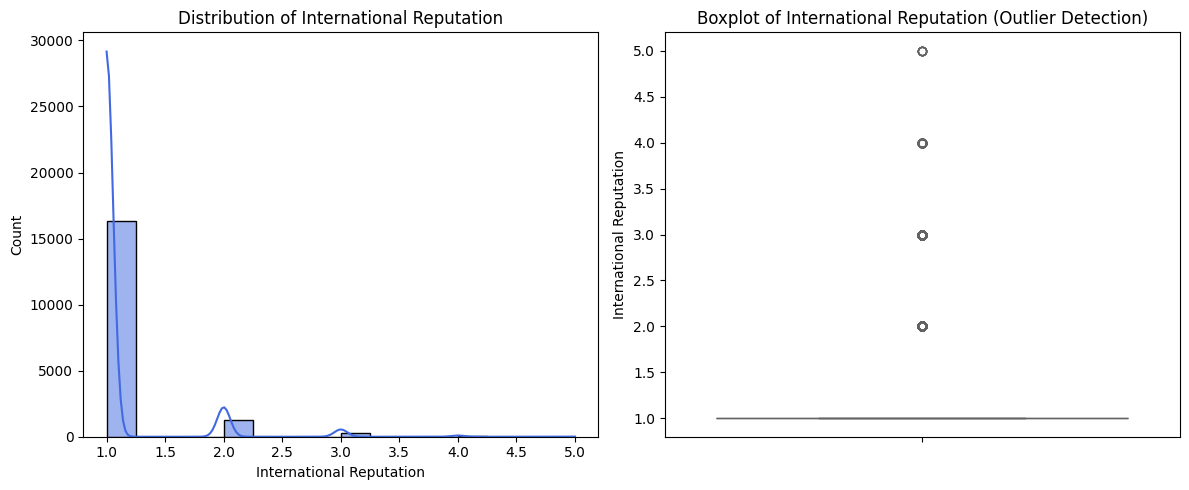

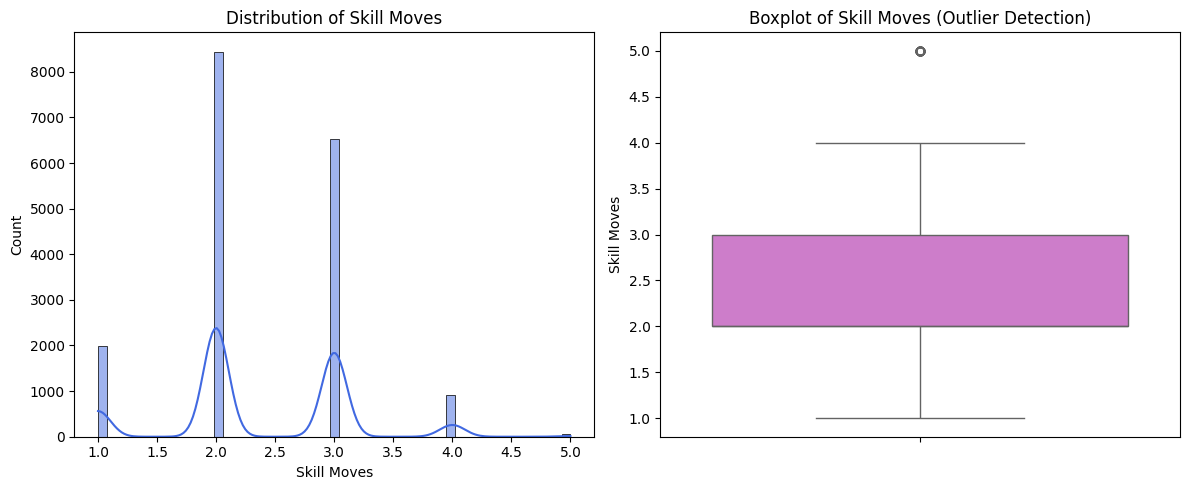

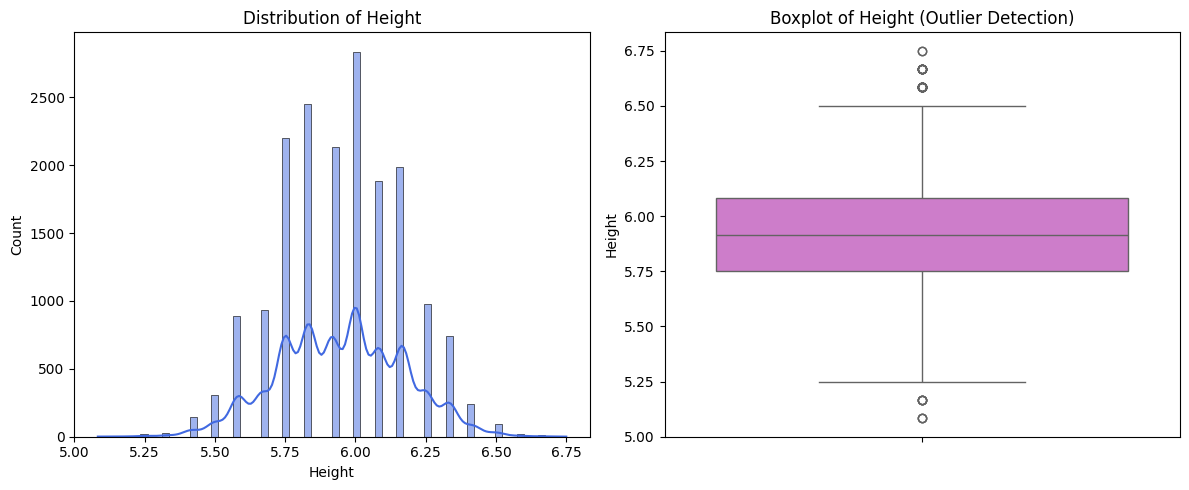

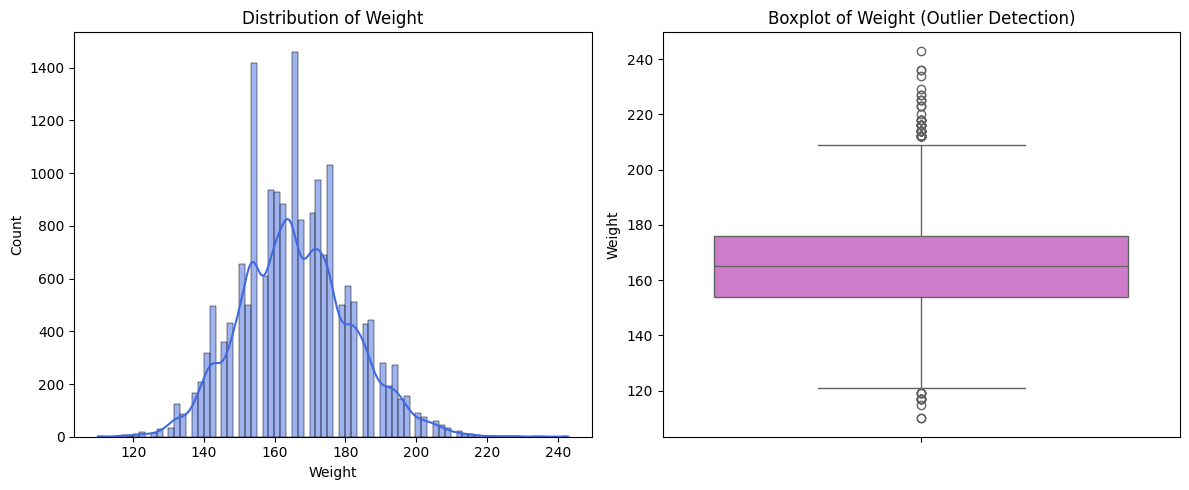

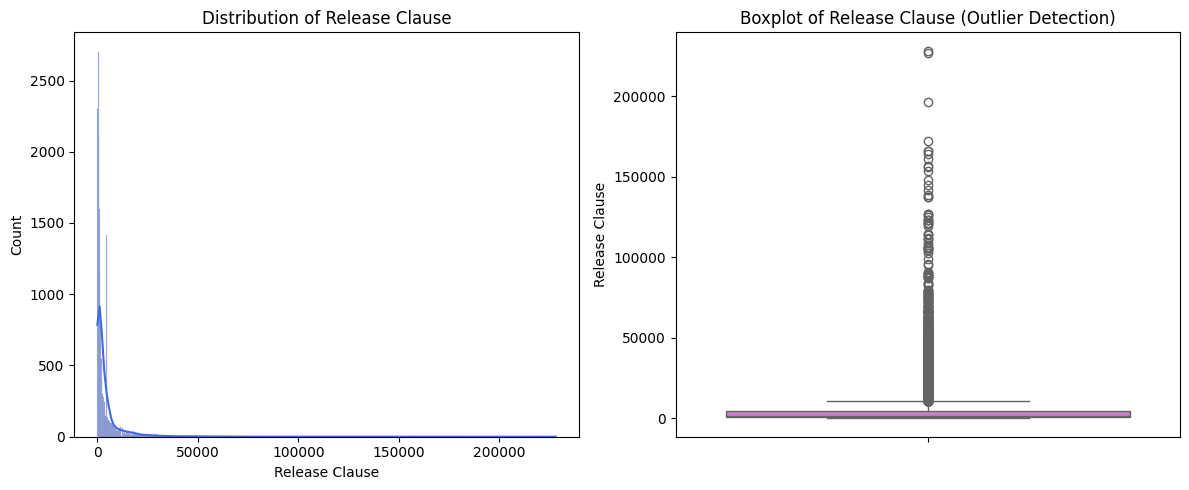

In [20]:
num_cols = df.select_dtypes(include=[np.number], exclude=['datetime', 'datetime64']).columns
for col in num_cols:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(df[col].dropna(), kde=True, color='royalblue')
    plt.title(f'Distribution of {col}')

    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[col].dropna(), color='orchid')
    plt.title(f'Boxplot of {col} (Outlier Detection)')

    plt.tight_layout()
    plt.show()

*  `ID` - It is a unique value given to each footballer so the skewness and the presence of **outliers** is justified.
*  `Age` - Age is slightly **right-skewed**, indicating a higher proportion of younger players compared to older veterans. There are **outliers** present in this feature which are to be dealt with. Might need standardisation/normalisation before using it in modelling.
*  `Overall`,`Potential`,`Height` and `Weight` - All are normally distributed but there are many **outliers** present which need to be dealt with.
*  `Value`,`Wage` and `Release Clause` - These are heavily **right-skewed** showing majority of the players have low net worth and are less paid. This shows many players surely have started their career as a footballer but very few reach the top. There is presence of many **outliers** which need to be dealt with. These three features also follow the same trend so might be **collinear** to each other.
*  `International Reputation` and `Skill Moves` - These two features are player ratings from 1 to 5. Both are **slightly right-skewed** like other features. There are **class imbalances** and **outliers** as well.

###4.2 Categorical Feature Frequency

Visualizing class frequencies helps identify class imbalances which is crucial for machine learning tasks.

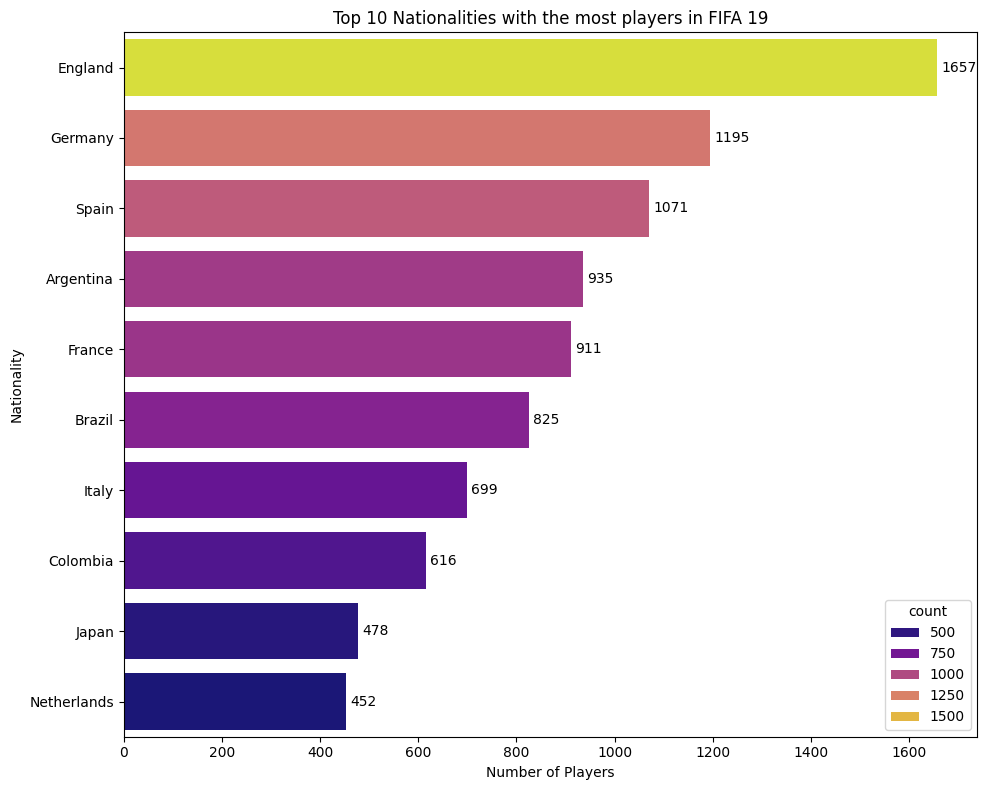

In [21]:
top_10_values = df['Nationality'].value_counts().head(10)

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=top_10_values.values, y=top_10_values.index.astype(str), hue=top_10_values, palette='plasma')
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Top 10 Nationalities with the most players in FIFA 19')
plt.xlabel('Number of Players')
plt.ylabel('Nationality')
plt.tight_layout()
plt.show()

Here, we can get a glimpse of the countries which produce the most number of football players mentioning names like `England`, `Germany`, `Spain`, `Argentina` and `France`.

In [22]:
df['Club'].value_counts().head(20)

,count
Club,
AS Monaco,33
Liverpool,33
Manchester City,33
Manchester United,33
Atlético Madrid,33
Borussia Dortmund,33
Real Madrid,33
TSG 1899 Hoffenheim,33
RC Celta,33


Here, we can see that `Club` has a lot of `value_counts` so there is no use of trying to find the club which have the most players.

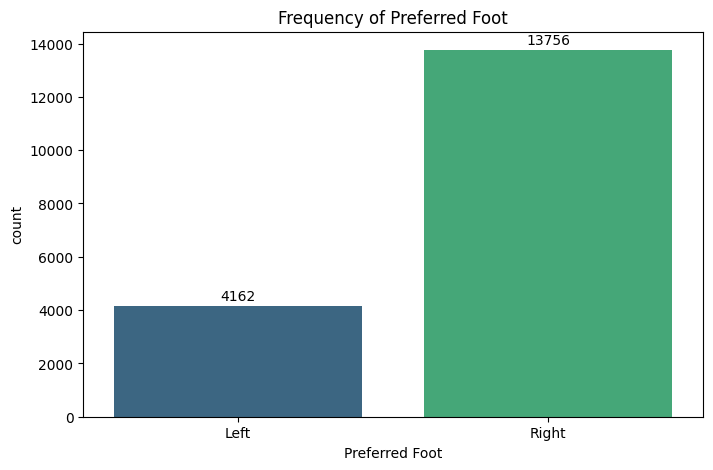

In [23]:
plt.figure(figsize=(8, 5))
ax=sns.countplot(x='Preferred Foot', data=df, hue='Preferred Foot', palette='viridis')
for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.title('Frequency of Preferred Foot')
plt.show()

We can clearly see the class imbalance of **left-footed** and **right-footed** players.

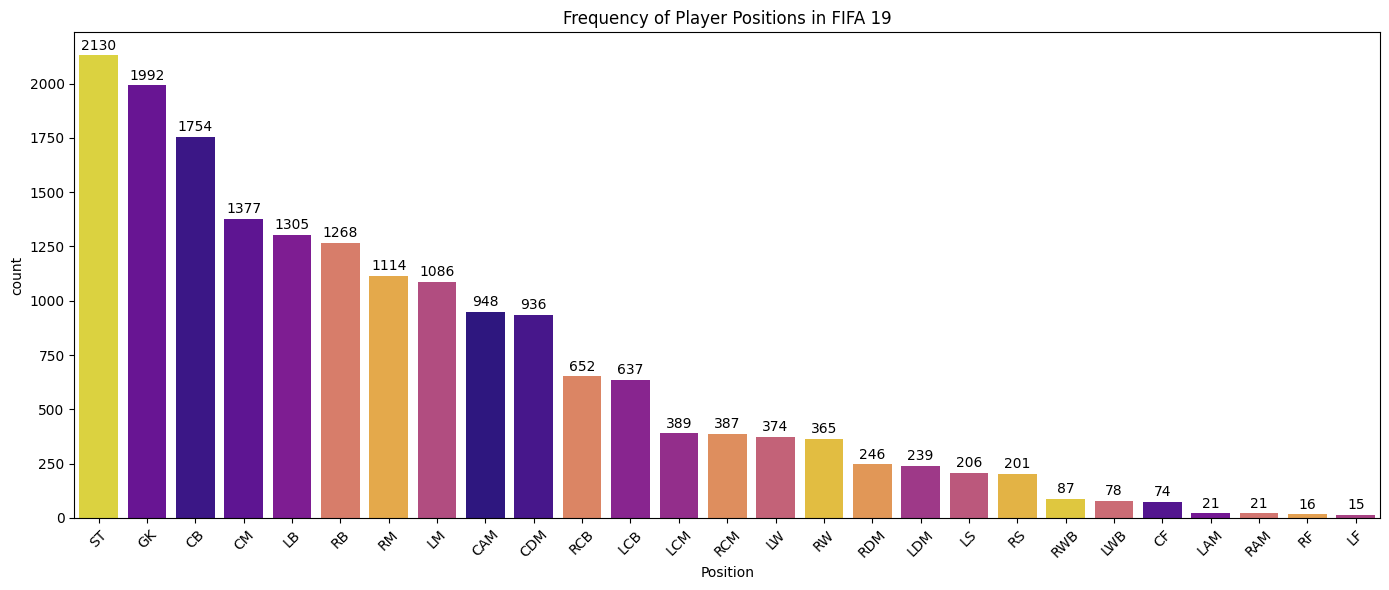

In [24]:
plt.figure(figsize=(14, 6))
position_order = df['Position'].value_counts().index
ax = sns.countplot(x='Position', data=df, hue='Position', palette='plasma',
                   order=position_order, legend=False)
for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.title('Frequency of Player Positions in FIFA 19')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We can clearly notice that among a lot of positions in which the players play in, the most chosen or most popular are `ST` (Striker), `GK` (GoalKeeper) and `CB` (Center Back).

## 5. BIVARIATE & MULTIVARIATE ANALYSIS

###5.1 Correlation Matrix

Evaluating linear relationships between numerical features to find strong dependencies and screen for multi-collinearity.

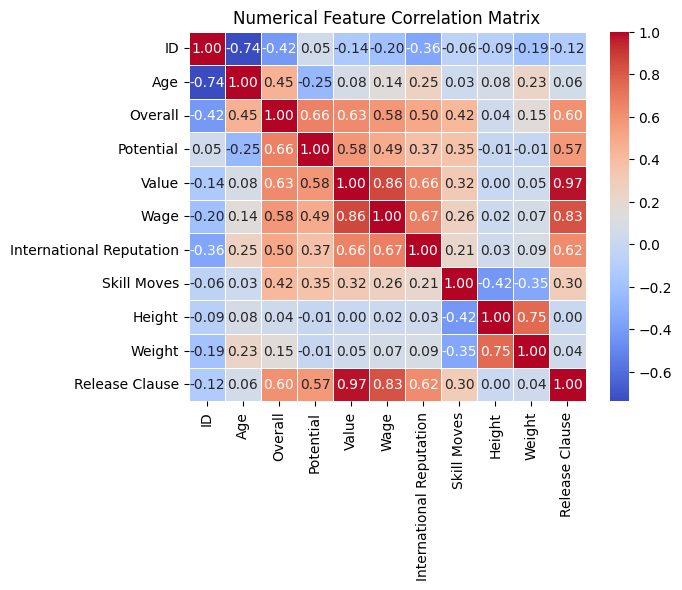

In [25]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Numerical Feature Correlation Matrix')
plt.show()

###5.2 Scatter Plots

Checking specific relationships between two highly correlated numerical variables.

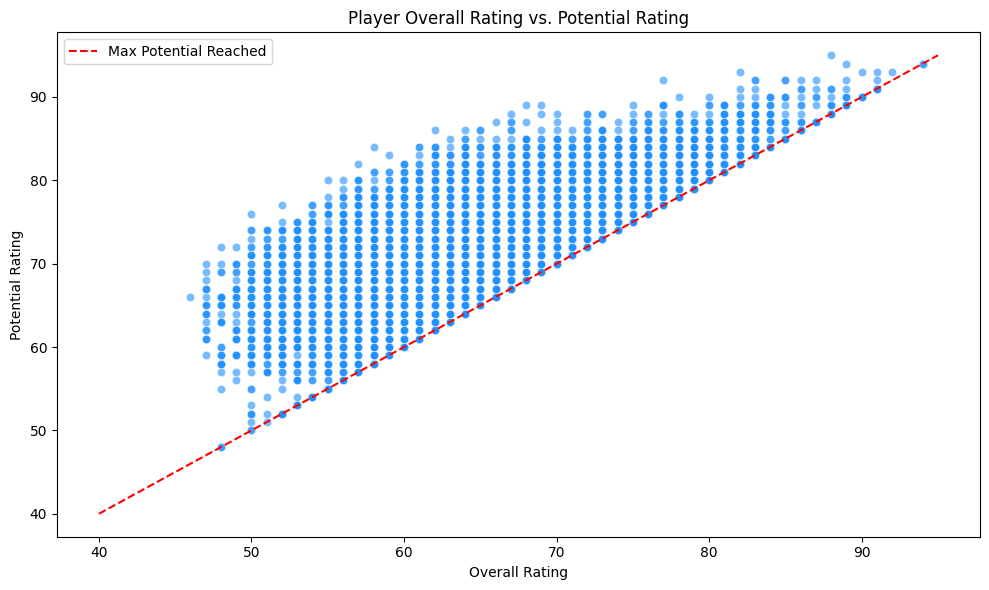

In [26]:
# 1. Overall vs. Potential
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Overall', y='Potential', data=df, alpha=0.6, color='dodgerblue')
plt.title('Player Overall Rating vs. Potential Rating')
plt.xlabel('Overall Rating')
plt.ylabel('Potential Rating')
# Adding a reference line where Overall = Potential
plt.plot([40, 95], [40, 95], color='red', linestyle='--', linewidth=1.5, label='Max Potential Reached')
plt.legend()
plt.tight_layout()
plt.show()

Firstly `Overall` and `Potential` show a positive linear relationship as expected. Here we can see that all players have much more potential than their overall rating.

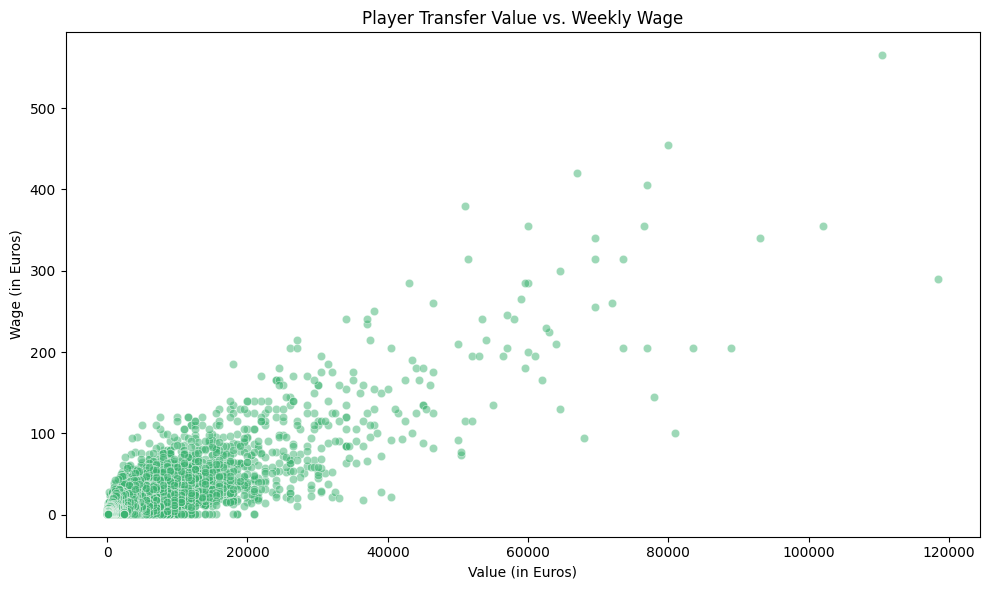

In [27]:
# 2. Wage vs. Value
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Value', y='Wage', data=df, alpha=0.5, color='mediumseagreen')
plt.title('Player Transfer Value vs. Weekly Wage')
plt.xlabel('Value (in Euros)')
plt.ylabel('Wage (in Euros)')
plt.tight_layout()
plt.show()

As we previously saw, `Value` and `Wage` are **linearly related** and their individual distribution being **right skewed** is clearly visible in the plot as well.

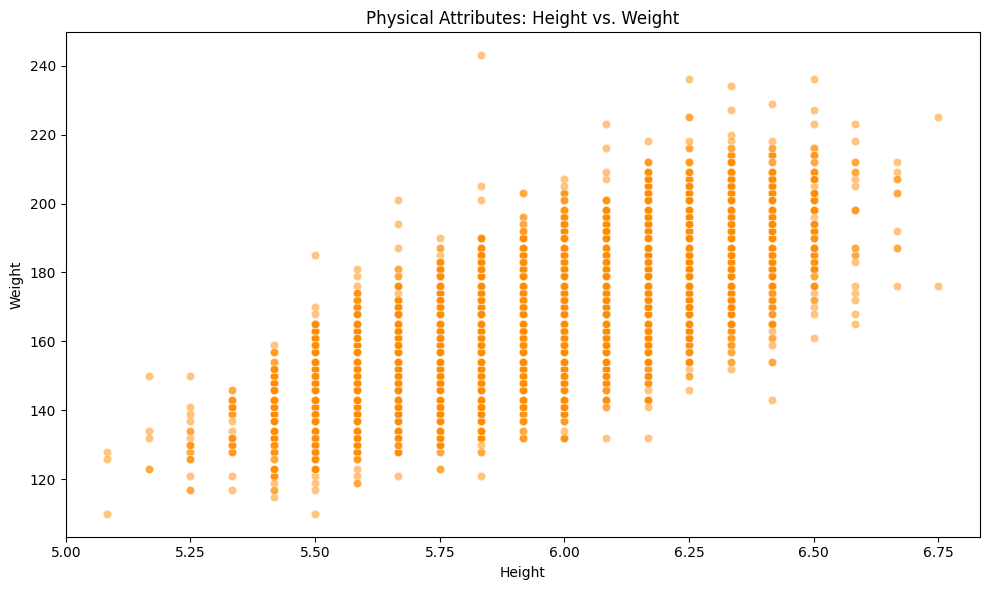

In [28]:
# 3. Height vs. Weight
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Height', y='Weight', data=df, alpha=0.5, color='darkorange')
plt.title('Physical Attributes: Height vs. Weight')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.tight_layout()
plt.show()

`Height` and `Weight` follow a strict positive relationship and hence might not add much value to the model if both are included. Might need feature engineering.

###5.3 Grouped Box Plots

Observing how numerical values vary across different categorical groups to identify distinguishing features.

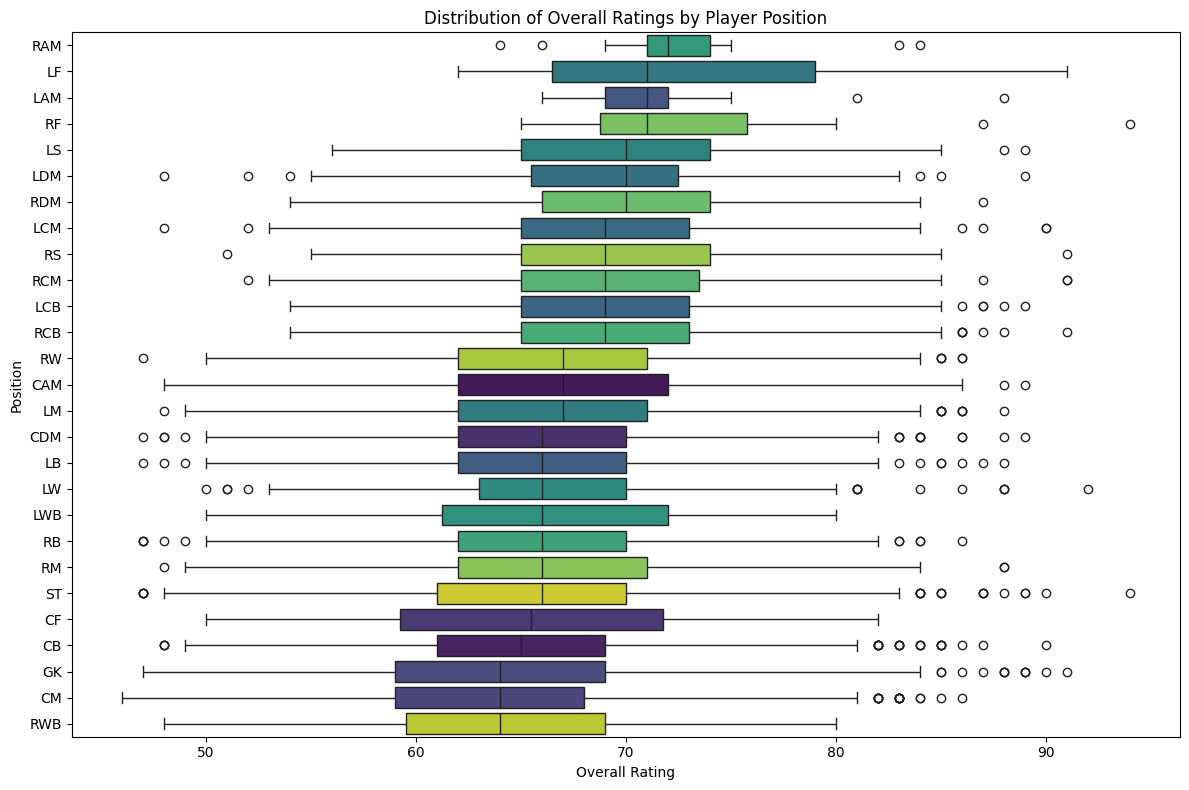

In [29]:
plt.figure(figsize=(12, 8))
position_order = df.groupby('Position', observed=False)['Overall'].median().sort_values(ascending=False).index
sns.boxplot(x='Overall', y='Position', data=df, hue='Position', order=position_order, palette='viridis', legend=False)
plt.title('Distribution of Overall Ratings by Player Position')
plt.xlabel('Overall Rating')
plt.ylabel('Position')
plt.tight_layout()
plt.show()

If we notice the `median` of ratings in each `boxplot` of positions. The highest median Overall ratings are given to `RAM` (Right-Attacking MidFielder), `LF` (Left Forward), `LAM` (Left-Attacking MidFielder) and `RF` (Right Forward). These positions are responsible for creativity and impact in the matches they play in. So, overall rating is not just influenced by the performance but also the creativity and chances created.

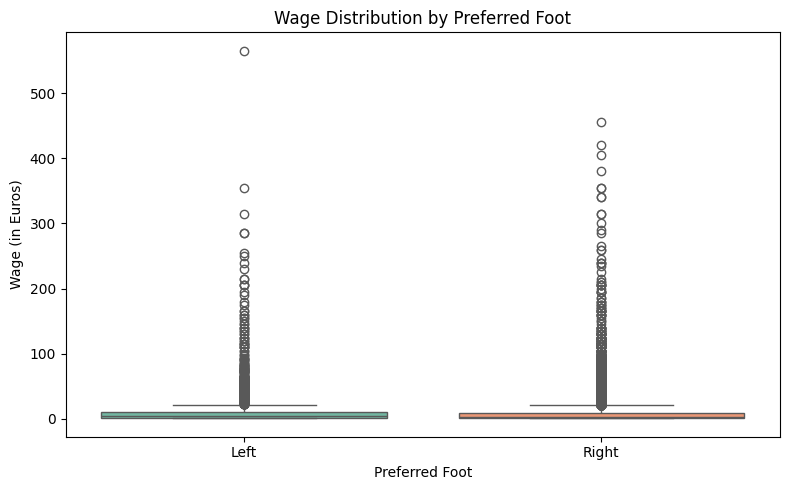

In [30]:
# 2. Wage by Preferred Foot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Preferred Foot', y='Wage', data=df, hue='Preferred Foot', palette='Set2')
plt.title('Wage Distribution by Preferred Foot')
plt.xlabel('Preferred Foot')
plt.ylabel('Wage (in Euros)')
plt.tight_layout()
plt.show()

The `median` of both the `Left` and `Right` footed players are same. So, irrespective of the foot they play in, their wages do not appear to be dependent on their preferred foot.

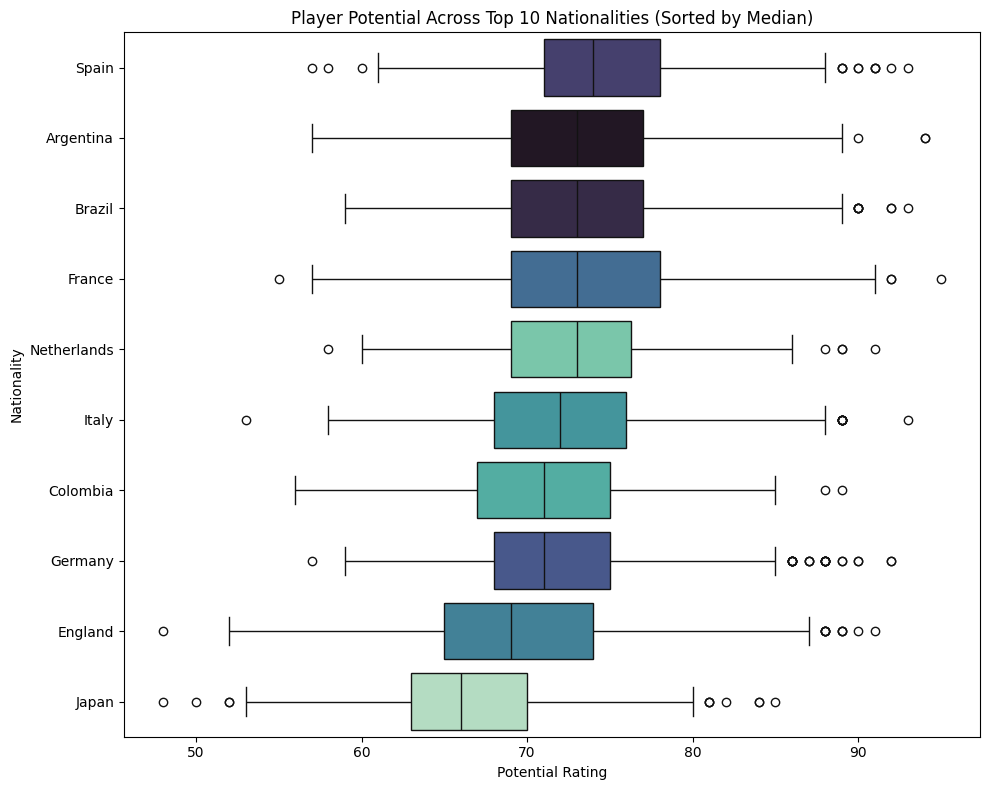

In [31]:
# 3. Potential by Top 10 Nationalities (Sorted by Median)
top_10_countries = df['Nationality'].value_counts().head(10).index
df_top_10 = df[df['Nationality'].isin(top_10_countries)].copy()
df_top_10['Nationality'] = df_top_10['Nationality'].astype(str)

median_order = df_top_10.groupby('Nationality')['Potential'].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 8))
sns.boxplot(
    x='Potential',
    y='Nationality',
    data=df_top_10,
    hue='Nationality',
    order=median_order,
    palette='mako',
    legend=False,
    dodge=False
)
plt.title('Player Potential Across Top 10 Nationalities (Sorted by Median)')
plt.xlabel('Potential Rating')
plt.ylabel('Nationality')
plt.tight_layout()
plt.show()

Even though `England` and `Germany` were the top two countries to provide the most football players, they do not necessarily guarantee the highest median potential for their players. On the other hand `Spain` and `Argentina` are the two countries having the most talented players.

## 6. Final Summary & Insights

###6.1 Key Takeaways

1. **Extreme Financial Skewness**: The distributions for `Value`, `Wage`, and `Release Clause` are heavily right-skewed. The vast majority of players earn a baseline wage, while a select few superstar outliers command astronomically higher financial figures, stretching the distribution significantly.  

2. **Predictive Power of Categorical Features**: A player's categorical attributes heavily influence their ceiling. For instance, specific creative roles (like `LAM` , `RAM` , and `LF`) tend to have higher median `Overall` ratings , and nations like `Spain` and `Argentina` boast distinctly higher median potentials compared to other top-producing countries.  

3. **High Multicollinearity Risk**: The correlation matrix and scatter plots reveal strict linear relationships between certain features. Specifically, `Height` vs. `Weight`  and `Value` vs. `Release Clause` are almost perfectly correlated, providing redundant information.  

###6.2 Model-Readiness Assessment

While the dataset is structurally sound with null values handled and data types corrected, it requires standard preprocessing before being fed into a machine learning algorithm:

1. **Feature Scaling**: Financial features (like `Wage`) operate on a massive scale compared to performance metrics (like `Overall` which caps at 99). A scaler (such as StandardScaler) must be applied to ensure distance-based models evaluate features equally.

2. **Categorical Encoding**: Algorithms require numerical input. `Preferred Foot` requires **Label Encoding** (`0` and `1`), while high-cardinality features like `Position` and `Nationality` require **One-Hot Encoding** to avoid implying a false mathematical hierarchy.

3. **Feature Selection**: To optimize model performance and prevent multicollinearity (especially for algorithms like `Naive Bayes` or `SVMs`), redundant features such as `Release Clause` and `Weight` should likely be dropped prior to training.